In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_ref = zipfile.ZipFile("/content/drive/MyDrive/AI GP Data/AIGP_8keypoints.zip", 'r')
zip_ref.extractall("/content/virtual/dataset")
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/AI GP Data/AIGP_PQ_8KEYPOINTS2.coco.zip", 'r')
zip_ref.extractall("/content/physical/dataset")
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/AI GP Data/gate frames-20260920T014241Z-1-001.zip", 'r')
zip_ref.extractall("/content/test/dataset")
zip_ref.close()

In [3]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.5 MB/s eta 0:00:00


In [4]:
import os
import json
import shutil
import glob
from pathlib import Path

NUM_KEYPOINTS = 8

def convert_coco_pose_folder(source_dir, output_root, split="train"):
    """
    Convert a folder containing:
      - images
      - _annotations.coco.json

    into YOLO pose format.
    """

    image_output = os.path.join(output_root, "images", split)
    label_output = os.path.join(output_root, "labels", split)

    os.makedirs(image_output, exist_ok=True)
    os.makedirs(label_output, exist_ok=True)

    # Find COCO annotation file
    json_files = glob.glob(os.path.join(source_dir, "*.json"))

    if not json_files:
        raise FileNotFoundError(
            f"No JSON annotation file found in {source_dir}"
        )

    json_path = json_files[0]

    print(f"\nProcessing:")
    print(source_dir)
    print("Annotations:", json_path)

    with open(json_path, "r") as f:
        coco = json.load(f)

    # image_id -> image metadata
    images = {
        img["id"]: img
        for img in coco["images"]
    }

    # group annotations by image
    annotations_by_image = {}

    for ann in coco["annotations"]:
        image_id = ann["image_id"]

        if image_id not in annotations_by_image:
            annotations_by_image[image_id] = []

        annotations_by_image[image_id].append(ann)

    total_images = 0
    labeled_images = 0
    total_objects = 0

    for image_id, image_info in images.items():

        filename = image_info["file_name"]
        width = image_info["width"]
        height = image_info["height"]

        source_image = os.path.join(source_dir, filename)
        target_image = os.path.join(image_output, filename)

        if not os.path.exists(source_image):
            print("Missing image:", source_image)
            continue

        shutil.copy2(source_image, target_image)

        total_images += 1

        txt_name = Path(filename).stem + ".txt"
        label_path = os.path.join(label_output, txt_name)

        annotations = annotations_by_image.get(image_id, [])

        lines = []

        for ann in annotations:

            # YOLO class 0 = gate
            class_id = 0

            # COCO bbox:
            # [x_min, y_min, width, height]
            x, y, box_w, box_h = ann["bbox"]

            # YOLO normalized bbox
            x_center = (x + box_w / 2) / width
            y_center = (y + box_h / 2) / height
            norm_w = box_w / width
            norm_h = box_h / height

            values = [
                class_id,
                x_center,
                y_center,
                norm_w,
                norm_h
            ]

            keypoints = ann.get("keypoints", [])

            if len(keypoints) != NUM_KEYPOINTS * 3:
                print(
                    f"Skipping bad annotation "
                    f"{ann.get('id')} in {filename}: "
                    f"expected 24 keypoint values, "
                    f"got {len(keypoints)}"
                )
                continue

            # Add 8 keypoints
            for i in range(NUM_KEYPOINTS):

                kp_x = keypoints[i * 3]
                kp_y = keypoints[i * 3 + 1]
                visibility = keypoints[i * 3 + 2]

                if visibility == 0:
                    kp_x_norm = 0.0
                    kp_y_norm = 0.0
                else:
                    kp_x_norm = kp_x / width
                    kp_y_norm = kp_y / height

                values.extend([
                    kp_x_norm,
                    kp_y_norm,
                    visibility
                ])

            line = " ".join(
                f"{v:.6f}" if isinstance(v, float) else str(v)
                for v in values
            )

            lines.append(line)
            total_objects += 1

        with open(label_path, "w") as f:
            f.write("\n".join(lines))

        if lines:
            labeled_images += 1

    print("\nFinished")
    print("Images:", total_images)
    print("Labeled images:", labeled_images)
    print("Gate annotations:", total_objects)

In [5]:
convert_coco_pose_folder(
    source_dir="/content/physical/dataset/AIGP_PQ_8KEYPOINTS.coco/train",
    output_root="/content/physical/dataset/AIGP_PQ_8KEYPOINTS_YOLO",
    split="train"
)
convert_coco_pose_folder(
    source_dir="/content/virtual/dataset/AIGP_8keypoints/train",
    output_root="/content/virtual/dataset/AIGP_8keypoints_YOLO",
    split="train"
)


Processing:
/content/physical/dataset/AIGP_PQ_8KEYPOINTS.coco/train
Annotations: /content/physical/dataset/AIGP_PQ_8KEYPOINTS.coco/train/_annotations.coco.json

Finished
Images: 142
Labeled images: 142
Gate annotations: 339

Processing:
/content/virtual/dataset/AIGP_8keypoints/train
Annotations: /content/virtual/dataset/AIGP_8keypoints/train/_annotations.coco.json
Skipping bad annotation 1 in gate_20260813_180553_0000009941_jpg.rf.mBScid1ZHvNM23AeE0Nm.jpg: expected 24 keypoint values, got 0
Skipping bad annotation 140 in gate_20260813_180553_0000010423_jpg.rf.M1MXQe217AnoxVfPXH7Y.jpg: expected 24 keypoint values, got 0
Skipping bad annotation 151 in gate_20260816_180331_0000001000_jpg.rf.JZMEy2CCfdqHzo6iVaNg.jpg: expected 24 keypoint values, got 0
Skipping bad annotation 155 in gate_20260816_180331_0000001012_jpg.rf.Ki6pNbrtuj7w2htT3fUc.jpg: expected 24 keypoint values, got 0
Skipping bad annotation 156 in gate_20260816_180331_0000001012_jpg.rf.Ki6pNbrtuj7w2htT3fUc.jpg: expected 24 ke

In [6]:
convert_coco_pose_folder(
    source_dir="/content/physical/dataset/AIGP_PQ_8KEYPOINTS.coco/valid",
    output_root="/content/physical/dataset/AIGP_PQ_8KEYPOINTS_YOLO",
    split="val"
)

convert_coco_pose_folder(
    source_dir="/content/virtual/dataset/AIGP_8keypoints/valid",
    output_root="/content/virtual/dataset/AIGP_8keypoints_YOLO",
    split="val"
)


Processing:
/content/physical/dataset/AIGP_PQ_8KEYPOINTS.coco/valid
Annotations: /content/physical/dataset/AIGP_PQ_8KEYPOINTS.coco/valid/_annotations.coco.json

Finished
Images: 35
Labeled images: 35
Gate annotations: 94

Processing:
/content/virtual/dataset/AIGP_8keypoints/valid
Annotations: /content/virtual/dataset/AIGP_8keypoints/valid/_annotations.coco.json

Finished
Images: 55
Labeled images: 55
Gate annotations: 103


In [40]:
from ultralytics import YOLO
import torch
import os

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Create a data.yaml file for training configuration
data_yaml_content = """
train:
  - /content/physical/dataset/AIGP_PQ_8KEYPOINTS_YOLO/images/train
  - /content/virtual/dataset/AIGP_8keypoints_YOLO/images/train

val:
  - /content/physical/dataset/AIGP_PQ_8KEYPOINTS_YOLO/images/val
  - /content/virtual/dataset/AIGP_8keypoints_YOLO/images/val

names:
  0: gate

kpt_shape: [8, 3]

# Keypoint order:
# 0 out_UL
# 1 out_UR
# 2 out_BR
# 3 out_BL
# 4 in_UL
# 5 in_UR
# 6 in_BR
# 7 in_BL
flip_idx: [1, 0, 3, 2, 5, 4, 7, 6]
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml_content)

print("data.yaml created successfully:")
with open("data.yaml", "r") as f:
    print(f.read())

# Load a pretrained YOLOv8 pose model (nano version for efficiency)
model = YOLO('yolov8n-pose.pt')


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
data.yaml created successfully:

train:
  - /content/physical/dataset/AIGP_PQ_8KEYPOINTS_YOLO/images/train
  - /content/virtual/dataset/AIGP_8keypoints_YOLO/images/train

val:
  - /content/physical/dataset/AIGP_PQ_8KEYPOINTS_YOLO/images/val
  - /content/virtual/dataset/AIGP_8keypoints_YOLO/images/val

names:
  0: gate

kpt_shape: [8, 3]

# Keypoint order:
# 0 out_UL
# 1 out_UR
# 2 out_BR
# 3 out_BL
# 4 in_UL
# 5 in_UR
# 6 in_BR
# 7 in_BL
flip_idx: [1, 0, 3, 2, 5, 4, 7, 6]



In [41]:
# Train the model
# Adjust epochs, imgsz, and other parameters as needed
print("Starting YOLO model training...")
results = model.train(
    data="data.yaml",
    epochs=250,
    patience=40,
    imgsz=640,  # Image size for training
    batch=-1,   # Auto batch size
    translate=0.30,
    degrees=15.0,
    perspective=0.001,
    scale=0.7,
    name="yolov8n_pose_combined_dataset_train", # Name for the training run results
    # Additional parameters can be added here, e.g., patience, optimizer, lr0 etc.
)

print("Training completed. Results can be found in runs/pose/yolov8n_pose_combined_dataset_train")

Starting YOLO model training...
Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=250, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_pose_co

In [88]:
weights = glob.glob(
    "/content/runs/pose/**/weights/best.pt",
    recursive=True
)

print("Found models:")
for w in weights:
    print(w)

# Choose most recently modified model
BEST_MODEL = max(weights, key=os.path.getmtime)

print("\nUsing newest model:")
print(BEST_MODEL)

model = YOLO(BEST_MODEL)

Found models:
/content/runs/pose/yolov8n_pose_combined_dataset_train-2/weights/best.pt
/content/runs/pose/yolov8n_pose_combined_dataset_train/weights/best.pt
/content/runs/pose/yolov8n_pose_combined_dataset_train-3/weights/best.pt
/content/runs/pose/yolov8n_pose_combined_dataset_train-5/weights/best.pt

Using newest model:
/content/runs/pose/yolov8n_pose_combined_dataset_train-5/weights/best.pt


In [89]:
import random

TEST_DIR = "/content/test/dataset/gate frames"

test_images = glob.glob(os.path.join(TEST_DIR, "*.jpg"))

print("Number of test images:", len(test_images))

# Pick 5 random test images
sample_images = random.sample(test_images, min(5, len(test_images)))

for img in sample_images:
    print(img)

Number of test images: 1207
/content/test/dataset/gate frames/0919_220524_000164.jpg
/content/test/dataset/gate frames/0919_214639_000141.jpg
/content/test/dataset/gate frames/0919_214639_000642.jpg
/content/test/dataset/gate frames/0919_220524_000126.jpg
/content/test/dataset/gate frames/0919_214639_000456.jpg


In [90]:
results = model.predict(
    source=sample_images,
    imgsz=640,
    conf=0.5,
    device=0,
    save=False,
    verbose=False
)

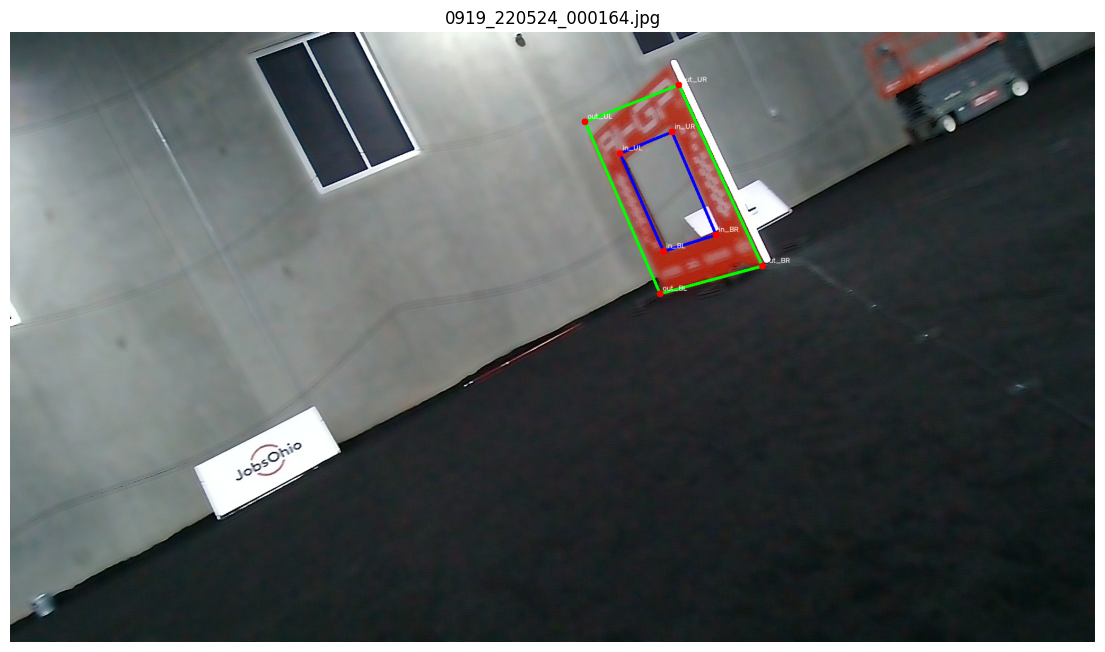

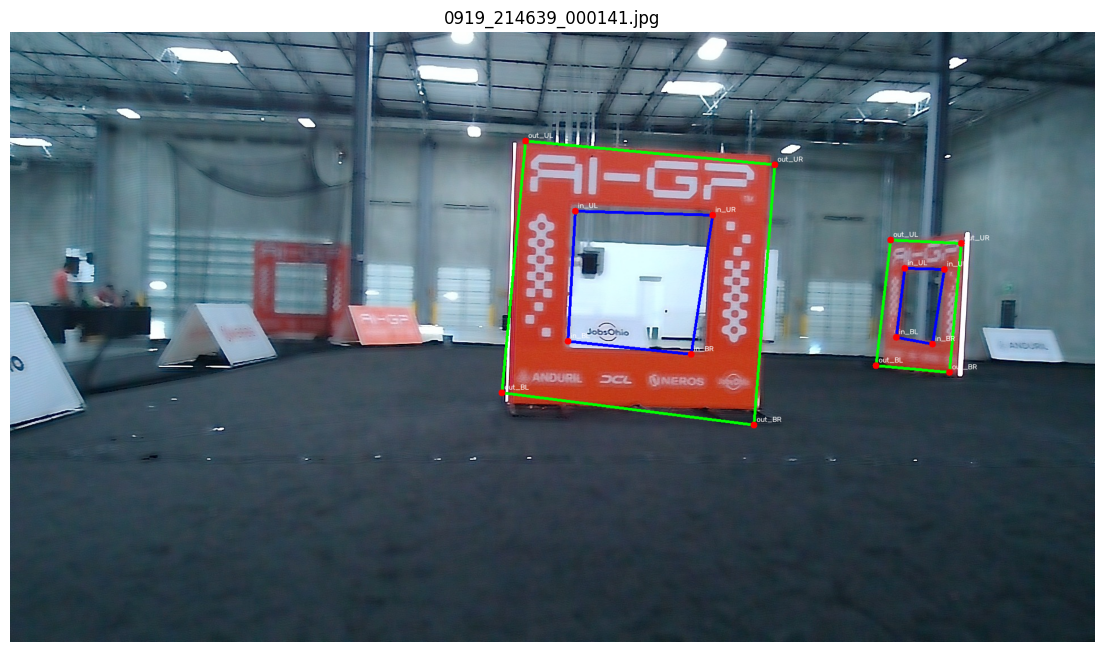

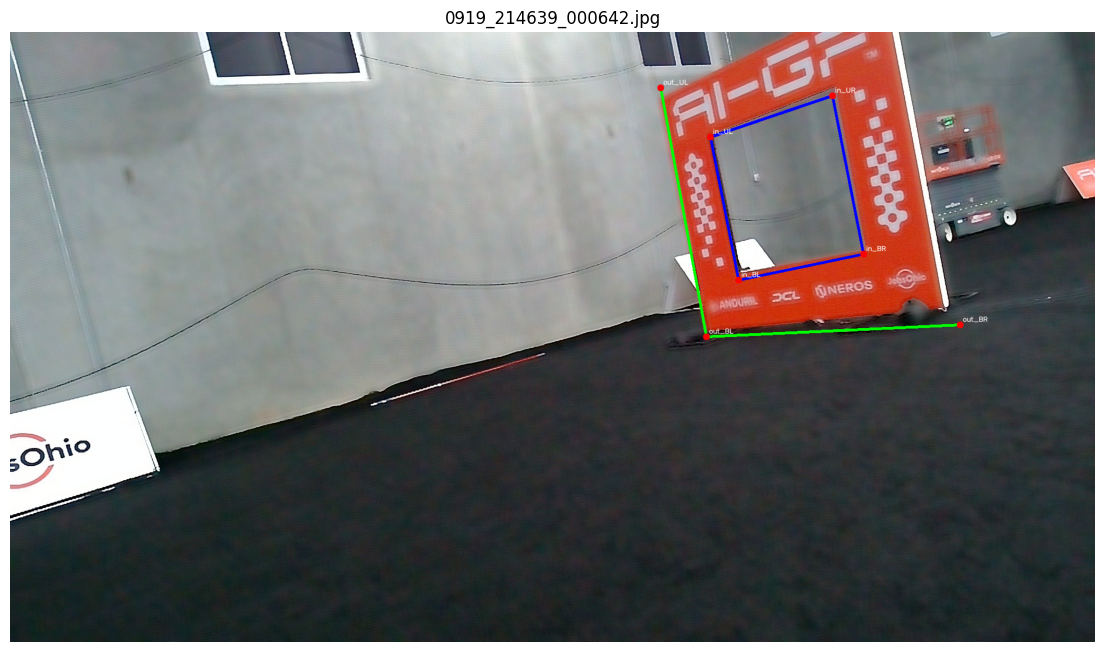

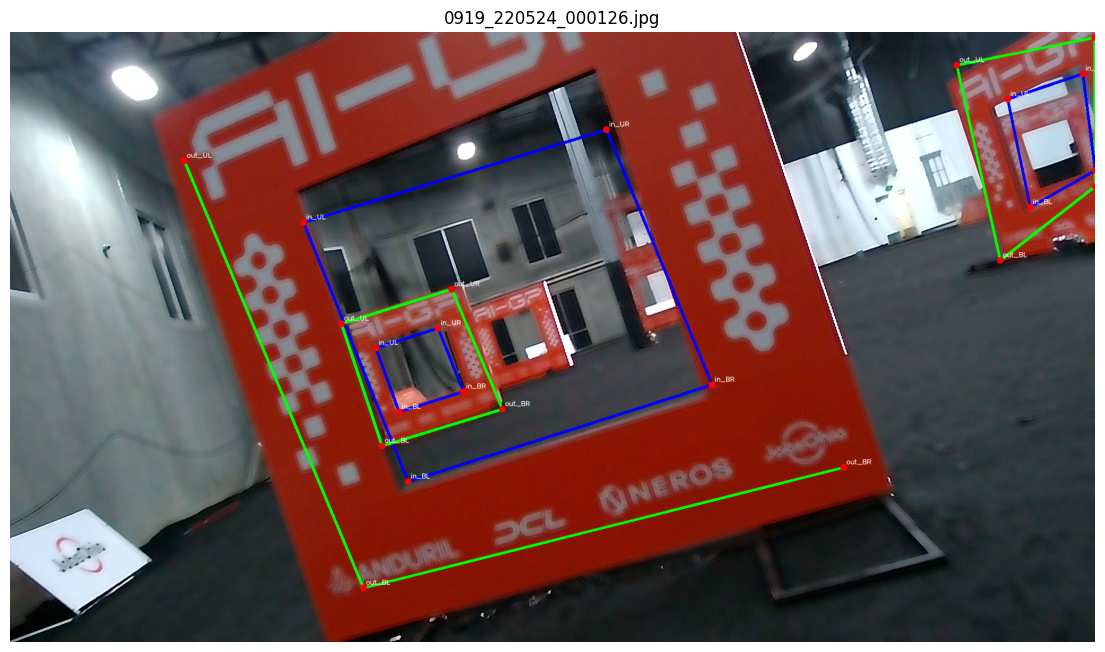

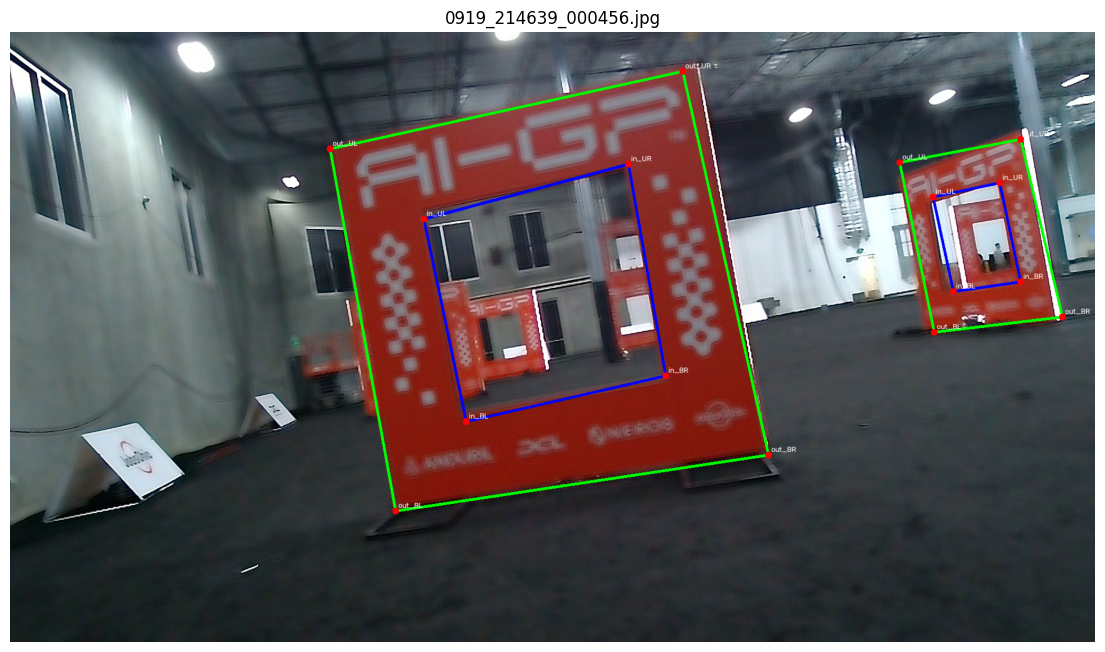

In [91]:
import cv2
import matplotlib.pyplot as plt
import os

KEYPOINT_NAMES = [
    "out_UL",
    "out_UR",
    "out_BR",
    "out_BL",
    "in_UL",
    "in_UR",
    "in_BR",
    "in_BL"
]

for result in results:

    # Read original image
    image = cv2.imread(result.path)

    # Draw each detected gate
    if result.keypoints is not None:

        for gate_idx in range(len(result.keypoints.xy)):

            points = result.keypoints.xy[gate_idx].cpu().numpy()

            # -------------------------
            # OUTER SQUARE
            # 0 -> 1 -> 2 -> 3 -> 0
            # -------------------------
            outer_indices = [0, 1, 2, 3, 0]

            for i in range(len(outer_indices) - 1):

                p1 = points[outer_indices[i]]
                p2 = points[outer_indices[i + 1]]

                # Ignore missing points
                if (
                    p1[0] > 0 and p1[1] > 0 and
                    p2[0] > 0 and p2[1] > 0
                ):
                    cv2.line(
                        image,
                        (int(p1[0]), int(p1[1])),
                        (int(p2[0]), int(p2[1])),
                        (0, 255, 0),
                        3
                    )

            # -------------------------
            # INNER SQUARE
            # 4 -> 5 -> 6 -> 7 -> 4
            # -------------------------
            inner_indices = [4, 5, 6, 7, 4]

            for i in range(len(inner_indices) - 1):

                p1 = points[inner_indices[i]]
                p2 = points[inner_indices[i + 1]]

                if (
                    p1[0] > 0 and p1[1] > 0 and
                    p2[0] > 0 and p2[1] > 0
                ):
                    cv2.line(
                        image,
                        (int(p1[0]), int(p1[1])),
                        (int(p2[0]), int(p2[1])),
                        (255, 0, 0),
                        3
                    )

            # -------------------------
            # DRAW KEYPOINTS
            # -------------------------
            for i, (x, y) in enumerate(points):

                if x <= 0 or y <= 0:
                    continue

                cv2.circle(
                    image,
                    (int(x), int(y)),
                    6,
                    (0, 0, 255),
                    -1
                )

                cv2.putText(
                    image,
                    KEYPOINT_NAMES[i],
                    (int(x) + 5, int(y) - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45,
                    (255, 255, 255),
                    1,
                    cv2.LINE_AA
                )

    # Convert BGR -> RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 8))
    plt.imshow(image_rgb)
    plt.title(os.path.basename(result.path))
    plt.axis("off")
    plt.show()